In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, json

from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:
train_ml = pd.read_csv("train_ml.csv")
val_ml   = pd.read_csv("val_ml.csv")
test_ml  = pd.read_csv("test_ml.csv")

with open("city_map.json") as f:
    city_map = {int(k): v for k, v in json.load(f).items()}

with open("features.json") as f:
    meta = json.load(f)

TARGET = "PM2.5"

X_train = train_ml.drop(columns=[TARGET])
y_train = train_ml[TARGET]
X_val   = val_ml.drop(columns=[TARGET])
y_val   = val_ml[TARGET]
X_test  = test_ml.drop(columns=[TARGET])
y_test  = test_ml[TARGET]

print("Train:", X_train.shape)
print("Val:  ", X_val.shape)
print("Test: ", X_test.shape)

FileNotFoundError: [Errno 2] No such file or directory: 'train_ml.csv'

In [ ]:
# Reusable function — we'll use this for every model
def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  R²   : {r2:.4f}")
    return {"model": name, "RMSE": rmse, "MAE": mae, "R2": r2}

# Store all model results here for final comparison
results = []

In [ ]:
# Strategy: always predict the mean of training PM2.5
baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train, y_train)

base_preds_val  = baseline.predict(X_val)
base_preds_test = baseline.predict(X_test)

val_result  = evaluate("Baseline — Validation", y_val,  base_preds_val)
test_result = evaluate("Baseline — Test",       y_test, base_preds_test)

results.append(test_result)


  Baseline — Validation
  RMSE : 22.9829
  MAE  : 12.7894
  R²   : -0.0052

  Baseline — Test
  RMSE : 38.8311
  MAE  : 23.0528
  R²   : -0.1865


In [ ]:
print("\n=== Baseline Per City RMSE (Test) ===")
test_ml["pred"] = base_preds_test

for city_id, city_name in sorted(city_map.items()):
    subset = test_ml[test_ml["City_id"] == city_id]
    if len(subset) == 0:
        continue
    rmse = np.sqrt(mean_squared_error(subset[TARGET], subset["pred"]))
    print(f"  {city_name:20s} → RMSE: {rmse:.4f}  (n={len(subset):,})")

test_ml.drop(columns=["pred"], inplace=True)


=== Baseline Per City RMSE (Test) ===
  Amaravati            → RMSE: 36.7177  (n=2,208)
  Anantapur            → RMSE: 23.9687  (n=2,208)
  Chittoor             → RMSE: 52.7230  (n=2,208)
  Kadapa               → RMSE: 21.1675  (n=2,208)
  Rajamahendravaram    → RMSE: 42.6850  (n=2,208)
  Tirupati             → RMSE: 38.6422  (n=2,208)
  Vijayawada           → RMSE: 11.7818  (n=2,208)
  Visakhapatnam        → RMSE: 58.8075  (n=2,208)


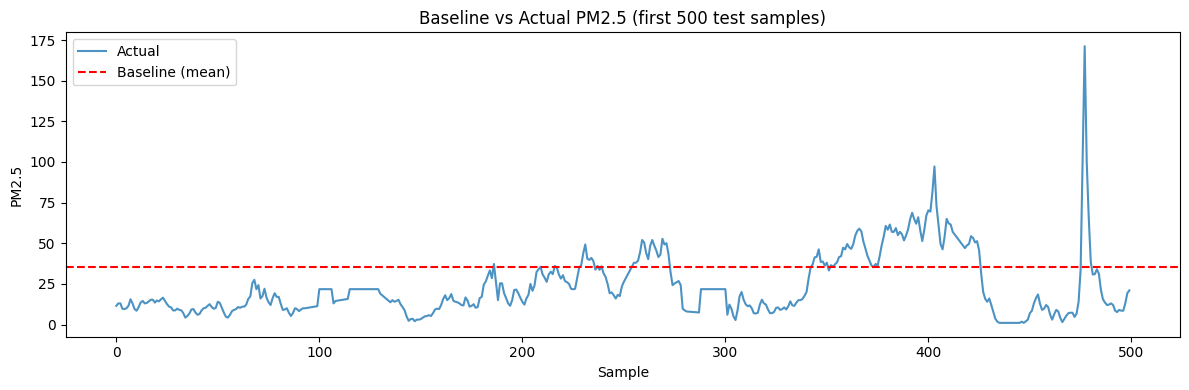

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(y_test.values[:500], label="Actual", alpha=0.8)
plt.axhline(base_preds_test[0], color="red", linestyle="--", label="Baseline (mean)")
plt.title("Baseline vs Actual PM2.5 (first 500 test samples)")
plt.xlabel("Sample")
plt.ylabel("PM2.5")
plt.legend()
plt.tight_layout()
plt.show()